# Cross-League Disciplinary Analysis
## Premier League, La Liga and Bundesliga

In notebook 04 we identified five persistent outliers in Serie A — teams whose
yellow-card-per-foul rate deviates significantly from the rest of the league across
multiple seasons, even when no single season alone would be conclusive.

Before diving into the *why* (notebook 06), we ask a prior question:

> **Is what we see in Italy a Serie A phenomenon, or does it appear in other major
> European leagues too?**

This notebook applies exactly the same methodology — no new tests, no new metrics —
to the **Premier League**, **La Liga** and **Bundesliga** across the same 15 seasons
(2011/12 to 2025/26).  We start with the most recent (incomplete) season as a
sanity check, then expand to the full multi-season analysis, and close with a
direct comparison against the Italian results.

## Section 1 — Data

In [1]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import sys
sys.path.insert(0, '..')
from src.multi_season import fmt_season, fmt_pvalue, make_pivot, run_full_pipeline
from src.plots import grey_missing

os.makedirs('../data/processed/notebook05', exist_ok=True)

In [2]:
with open('../data/processed/team_matches.pkl', 'rb') as f:
    tm = pickle.load(f)

LEAGUES = {
    'Premier_League': 'Premier League',
    'La_Liga':        'La Liga',
    'Bundesliga':     'Bundesliga',
}

# Split into one DataFrame per league (all seasons)
dfs = {key: tm[tm['league'] == key].copy() for key in LEAGUES}

# Add crude rate column
for key in dfs:
    dfs[key]['crude_rate'] = dfs[key]['yellow_cards'] / dfs[key]['fouls_committed']

In [3]:
# Coverage table
seasons = sorted(tm['season'].unique())
readable_seasons = [fmt_season(s) for s in seasons]

rows = []
for key, label in LEAGUES.items():
    df = dfs[key]
    for s in seasons:
        n_teams = df[df['season'] == s]['team'].nunique()
        n_rows  = len(df[df['season'] == s])
        rows.append(dict(league=label, season=fmt_season(s),
                         teams=n_teams, match_rows=n_rows))

coverage = pd.DataFrame(rows)
pivot_teams = coverage.pivot(index='league', columns='season', values='teams')
print("Teams per season per league:")
display(pivot_teams)

Teams per season per league:


season,2011-12,2012-13,2013-14,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25,2025-26
league,,,,,,,,,,,,,,,
Bundesliga,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18
La Liga,20,20,20,20,20,20,20,20,20,20,20,20,20,20,20
Premier League,20,20,20,20,20,20,20,20,20,20,20,20,20,20,20


### Data notes

- All three leagues cover the same 15 seasons (2011/12 to 2025/26) from the same
  data source, ensuring internal consistency in team names and column definitions.
- **Bundesliga has 18 clubs** per season, compared to 20 in the Premier League and
  La Liga. This means a slightly smaller "rest of league" pool for each team test
  — a minor difference that we acknowledge but does not affect the methodology.
- **2025/26 is an incomplete season** (data up to the point of collection).
  Results for this season should be read as provisional.

## Section 2 — 2025/26: a first look across leagues

In notebook 03 we tested a single Serie A season and found Juventus as a clear
outlier.  Here we ask the same question for the three new leagues: **in the most
recent season, are there teams whose yellow-card-per-foul rate deviates
significantly from their peers?**

We use the same two tests applied in notebook 04 — bootstrap and Mann-Whitney U —
skipping the z-test screening used for season selection (it is redundant when we
are testing all teams at once).  The rank-biserial correlation $r_{rb}$ measures
effect size: negative means fewer cards per foul than the rest of the league,
positive means more.

In [4]:
def run_boot_mw(team_name, df, n_bootstrap=10_000, seed=42):
    """
    Bootstrap + Mann-Whitney pipeline for one team against the rest of a
    single-season (or pooled) DataFrame.

    Returns a dict with: team, n, k, p_hat, p0, p_boot, p_mw, r_rb.
    """
    team_df = df[df['team'] == team_name].copy()
    rest_df = df[df['team'] != team_name].copy()
    n     = int(team_df['fouls_committed'].sum())
    k     = int(team_df['yellow_cards'].sum())
    if n == 0:
        return None
    p_hat = k / n
    p0    = float(rest_df['yellow_cards'].sum() / rest_df['fouls_committed'].sum())
    m     = len(team_df)

    rng = np.random.default_rng(seed)
    null_rates = np.array([
        rest_df.sample(n=m, replace=True,
                       random_state=int(rng.integers(1_000_000_000)))['yellow_cards'].sum() /
        rest_df.sample(n=m, replace=True,
                       random_state=int(rng.integers(1_000_000_000)))['fouls_committed'].sum()
        for _ in range(n_bootstrap)
    ])
    null_mean = null_rates.mean()
    p_boot = float((np.abs(null_rates - null_mean) >= abs(p_hat - null_mean)).mean())

    tr = (team_df['yellow_cards'] / team_df['fouls_committed']
          ).replace([np.inf, -np.inf], np.nan).dropna()
    rr = (rest_df['yellow_cards'] / rest_df['fouls_committed']
          ).replace([np.inf, -np.inf], np.nan).dropna()
    u, p_mw = stats.mannwhitneyu(tr, rr, alternative='two-sided')
    r_rb = float((2 * u) / (len(tr) * len(rr)) - 1)

    return dict(team=team_name, n=n, k=k,
                p_hat=round(p_hat, 4), p0=round(p0, 4),
                p_boot=round(p_boot, 4), p_mw=round(p_mw, 4),
                r_rb=round(r_rb, 4))

In [5]:
# --- Load results from cache if available ---
_path_2526 = '../data/processed/notebook05/season_2526.pkl'

if os.path.exists(_path_2526):
    with open(_path_2526, 'rb') as f:
        season_2526 = pickle.load(f)
    print("Loaded 2025/26 results from cache. Skip next cell.")
else:
    season_2526 = None
    print("No cache found - run the next cell.")

Loaded 2025/26 results from cache. Skip next cell.


In [6]:
# --- Run bootstrap + Mann-Whitney for all teams (skip if cache was loaded) ---
if season_2526 is None:
    season_2526 = {}
    for key, label in LEAGUES.items():
        df26 = dfs[key][dfs[key]['season'] == '2526'].copy()
        teams = sorted(df26['team'].unique())
        results = [run_boot_mw(t, df26) for t in teams]
        season_2526[key] = (pd.DataFrame([r for r in results if r])
                              .sort_values('r_rb')
                              .reset_index(drop=True))
        print(f"  {label}: done")

    with open(_path_2526, 'wb') as f:
        pickle.dump(season_2526, f)
    print("\nResults saved to cache.")
else:
    print("Using cached results - skipping computation.")

print("\nTeams tested per league:")
for key, label in LEAGUES.items():
    print(f"  {label}: {len(season_2526[key])} teams")

Using cached results - skipping computation.

Teams tested per league:
  Premier League: 20 teams
  La Liga: 20 teams
  Bundesliga: 18 teams


In [7]:
# Display results tables — one per league
for key, label in LEAGUES.items():
    res = season_2526[key].copy()
    res['p_boot'] = res['p_boot'].apply(fmt_pvalue)
    res['p_mw']   = res['p_mw'].apply(fmt_pvalue)
    res['r_rb']   = res['r_rb'].apply(lambda x: f'{x:+.3f}')
    res['card_rate']   = res['p_hat'].apply(lambda x: f'{x:.4f}')
    res['league_rate'] = res['p0'].apply(lambda x: f'{x:.4f}')
    print(f"\n{label}  —  2025/26  (sorted by r_rb, * = p < 0.05):")
    display(res[['team', 'card_rate', 'league_rate', 'p_boot', 'p_mw', 'r_rb']])


Premier League  —  2025/26  (sorted by r_rb, * = p < 0.05):


,team,card_rate,league_rate,p_boot,p_mw,r_rb
0,Arsenal,0.1266,0.1758,0.036 *,0.005 *,-0.297
1,Nott'm Forest,0.1468,0.1749,0.225,0.195,-0.138
2,Leeds,0.1522,0.1746,0.326,0.240,-0.125
3,West Ham,0.1525,0.1746,0.333,0.286,-0.113
4,Man United,0.1451,0.1749,0.202,0.330,-0.103
5,Aston Villa,0.1516,0.1746,0.324,0.344,-0.101
6,Everton,0.1631,0.1740,0.619,0.518,-0.069
7,Burnley,0.1645,0.1739,0.667,0.529,-0.067
8,Liverpool,0.1607,0.1741,0.553,0.584,-0.058
9,Newcastle,0.1572,0.1743,0.450,0.633,-0.051



La Liga  —  2025/26  (sorted by r_rb, * = p < 0.05):


,team,card_rate,league_rate,p_boot,p_mw,r_rb
0,Barcelona,0.1610,0.1755,0.529,0.115,-0.173
1,Sociedad,0.1398,0.1772,0.121,0.129,-0.167
2,Espanol,0.1633,0.1757,0.597,0.508,-0.073
3,Celta,0.1657,0.1755,0.659,0.578,-0.061
4,Alaves,0.1581,0.1761,0.456,0.640,-0.051
5,Real Madrid,0.1818,0.1747,0.788,0.735,-0.037
6,Valencia,0.1676,0.1754,0.734,0.753,-0.035
7,Ath Bilbao,0.1675,0.1755,0.725,0.763,-0.033
8,Elche,0.1592,0.1759,0.467,0.863,-0.019
9,Ath Madrid,0.1698,0.1753,0.806,0.870,-0.018



Bundesliga  —  2025/26  (sorted by r_rb, * = p < 0.05):


,team,card_rate,league_rate,p_boot,p_mw,r_rb
0,M'gladbach,0.1275,0.1849,0.039 *,0.015 *,-0.278
1,Hoffenheim,0.1330,0.1854,0.064,0.062,-0.213
2,Heidenheim,0.1552,0.1831,0.300,0.197,-0.147
3,St Pauli,0.1502,0.1833,0.222,0.260,-0.129
4,Dortmund,0.1529,0.1834,0.271,0.285,-0.122
5,RB Leipzig,0.1529,0.1831,0.269,0.304,-0.118
6,Freiburg,0.1720,0.1821,0.706,0.779,-0.032
7,Union Berlin,0.1753,0.1820,0.798,0.819,-0.026
8,Bayern Munich,0.1911,0.1811,0.736,0.914,-0.012
9,Wolfsburg,0.1761,0.1819,0.818,0.955,-0.006


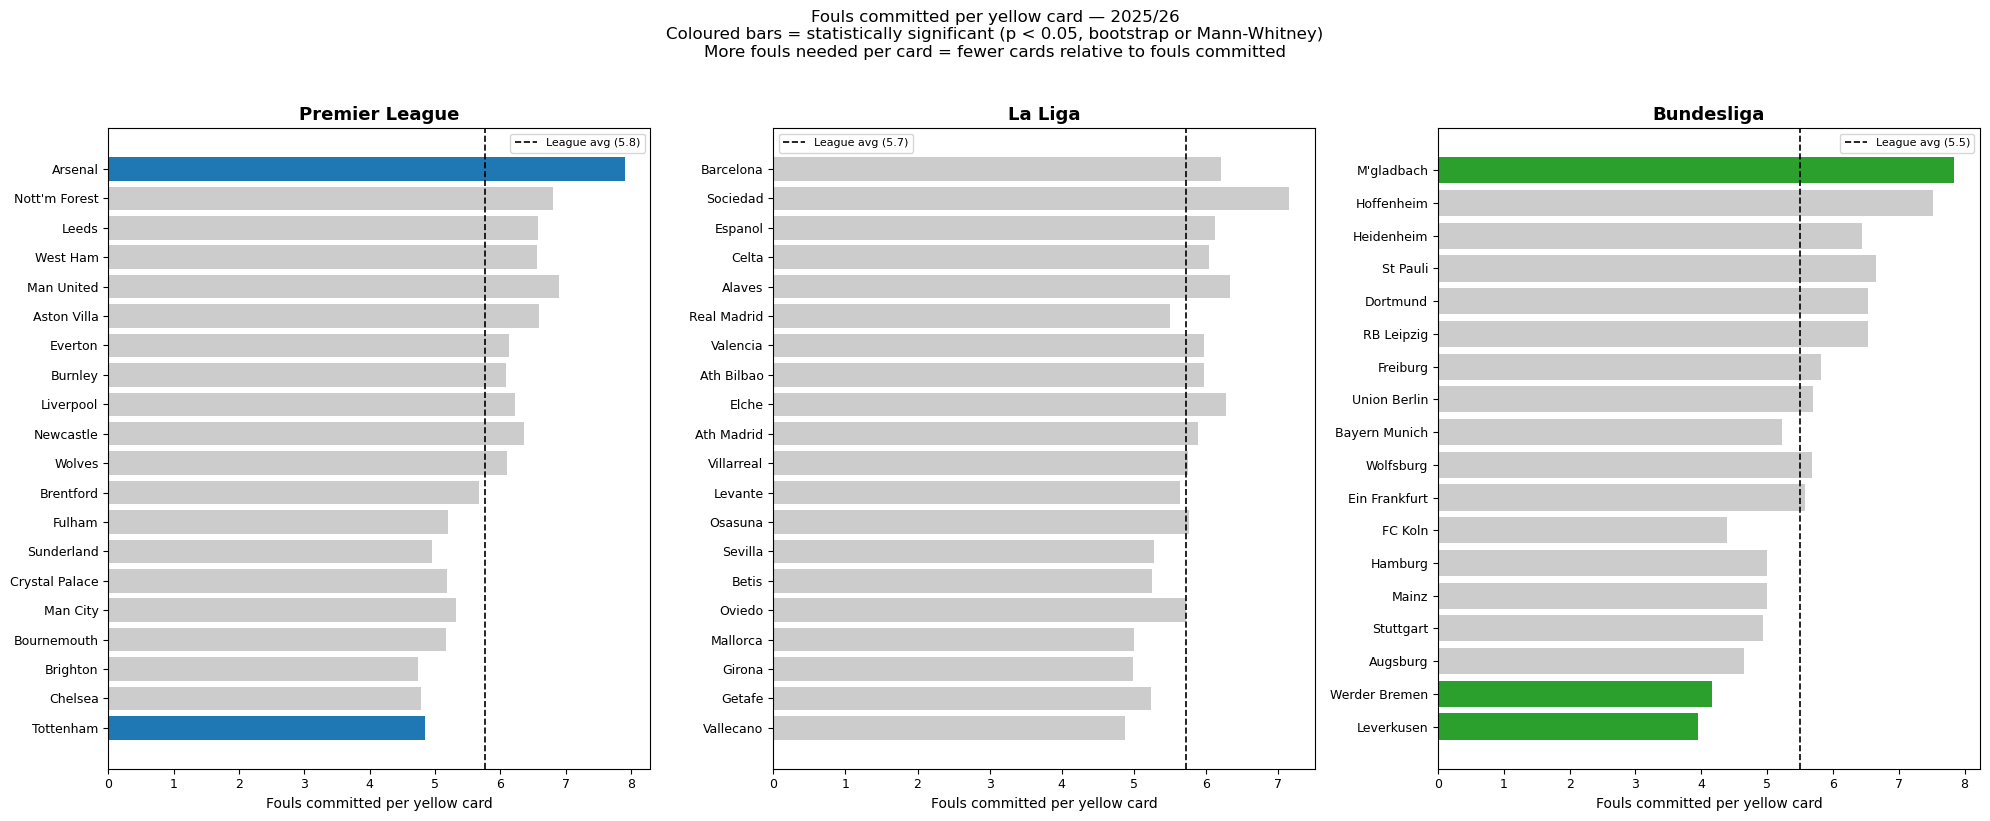

In [8]:
# Bar chart: fouls per card — more intuitive for non-technical readers
# Sort so the most "advantaged" teams (most fouls per card, fewest cards per foul)
# appear at the top of each panel.
# Statistical significance is still determined by bootstrap and Mann-Whitney on
# the cards-per-foul rate; we just display the inverse here for readability.

fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=False)
palette = {'Premier_League': '#1f77b4', 'La_Liga': '#d62728', 'Bundesliga': '#2ca02c'}

for ax, (key, label) in zip(axes, LEAGUES.items()):
    df26  = dfs[key][dfs[key]['season'] == '2526']
    league_fpc = df26['fouls_committed'].sum() / df26['yellow_cards'].sum()

    res = season_2526[key].copy()
    res['fouls_per_card'] = 1 / res['p_hat']
    # Sort by r_rb descending: most positive r_rb (most cards per foul) at bottom,
    # most negative (most advantaged) at top.  r_rb reflects the full per-match
    # distribution so it is a more principled ordering than the raw aggregate rate.
    res = res.sort_values('r_rb', ascending=False)

    colors = [
        palette[key] if (row['p_boot'] < 0.05 or row['p_mw'] < 0.05)
        else '#cccccc'
        for _, row in res.iterrows()
    ]
    ax.barh(res['team'], res['fouls_per_card'], color=colors)
    ax.axvline(league_fpc, color='black', linewidth=1.2, linestyle='--',
               label=f'League avg ({league_fpc:.1f})')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Fouls committed per yellow card', fontsize=10)
    ax.tick_params(labelsize=9)
    ax.legend(fontsize=8)

fig.suptitle('Fouls committed per yellow card — 2025/26\n'
             'Coloured bars = statistically significant (p < 0.05, bootstrap or Mann-Whitney)\n'
             'More fouls needed per card = fewer cards relative to fouls committed',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 2025/26 observations

**Premier League.**  Arsenal stand out as the only clearly significant low-rate team
(card rate 0.127 vs league 0.176, $r_{rb}$ = -0.30, $p_{MW}$ = 0.005): they commit
fouls that referees deem card-worthy less often than any other Premier League side
this season.  At the other end, Tottenham are the only significant high-rate team
($r_{rb}$ = +0.22, $p_{MW}$ = 0.037).

**A note on Tottenham vs Brighton and Chelsea.**  The bar chart places Brighton and
Chelsea *below* Tottenham — meaning they actually needed fewer fouls per card in
raw aggregate terms — yet only Tottenham is flagged as significant.  This is not a
contradiction; it is a window into what the Mann-Whitney test actually measures.

The aggregate (fouls per card, or its inverse the card rate) is a single number
computed from the season total.  A team can end up with a high aggregate card rate
simply because a few matches were unusually card-heavy, while most of their matches
looked perfectly normal.  Tottenham's elevated rate is *consistent* across
individual matches — match after match, their card rate tends to sit above the
league distribution.  Brighton and Chelsea have a noisier pattern: their averages
are pulled up by outlier matches rather than a persistent tendency.

The Mann-Whitney test is sensitive precisely to this consistency: it asks, across
every possible pairing of a Tottenham match with a non-Tottenham match, is the
Tottenham match more likely to have the higher card rate?  If yes, consistently,
the test returns a small p-value.  The following chart makes this concrete.

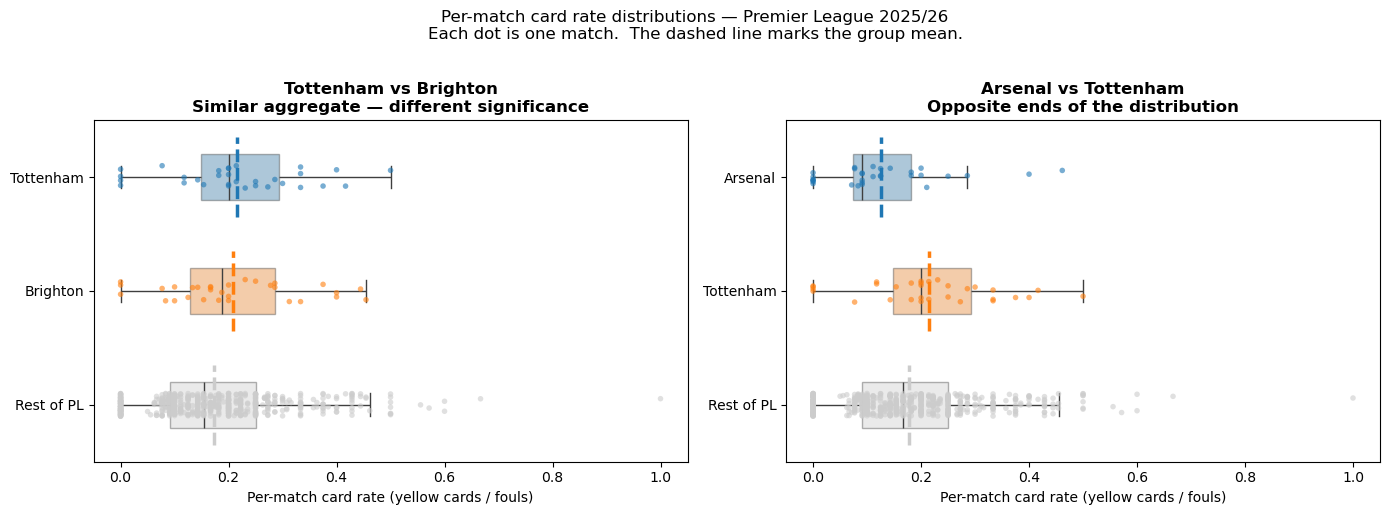

In [9]:
# Per-match distribution comparison — Premier League 2025/26
# Two panels: (1) Tottenham vs Brighton  (2) Arsenal vs Tottenham

df26_pl = dfs['Premier_League'][dfs['Premier_League']['season'] == '2526'].copy()
df26_pl['match_rate'] = (df26_pl['yellow_cards'] / df26_pl['fouls_committed']
                         ).replace([np.inf, -np.inf], np.nan)
df26_pl = df26_pl.dropna(subset=['match_rate'])

comparisons = [
    ('Tottenham', 'Brighton',
     'Tottenham vs Brighton\nSimilar aggregate — different significance'),
    ('Arsenal',   'Tottenham',
     'Arsenal vs Tottenham\nOpposite ends of the distribution'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (team_a, team_b, title) in zip(axes, comparisons):
    plot_df = df26_pl.copy()
    plot_df['group'] = plot_df['team'].apply(
        lambda t: team_a if t == team_a else (team_b if t == team_b else 'Rest of PL')
    )
    order  = [team_a, team_b, 'Rest of PL']
    colors = {'Rest of PL': '#cccccc', team_a: '#1f77b4', team_b: '#ff7f0e'}

    sns.boxplot(data=plot_df, x='match_rate', y='group', hue='group', order=order,
                palette=colors, width=0.4, fliersize=0, ax=ax, legend=False,
                boxprops=dict(alpha=0.4))
    sns.stripplot(data=plot_df, x='match_rate', y='group', hue='group', order=order,
                  palette=colors, size=4, alpha=0.6, jitter=True, ax=ax, legend=False)

    # Mark the group mean
    for i, grp in enumerate(order):
        mean_val = plot_df[plot_df['group'] == grp]['match_rate'].mean()
        ax.axvline(mean_val,
                   ymin=(2 - i) / 3 + 0.05, ymax=(3 - i) / 3 - 0.05,
                   color=colors[grp], linewidth=2.5, linestyle='--')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Per-match card rate (yellow cards / fouls)', fontsize=10)
    ax.set_ylabel('')
    ax.tick_params(labelsize=10)

fig.suptitle('Per-match card rate distributions — Premier League 2025/26\n'
             'Each dot is one match.  The dashed line marks the group mean.',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

The left panel illustrates the Tottenham/Brighton puzzle — and it is more
instructive than it first appears.  Brighton's mean per-match rate (dashed line)
sits slightly *left* of Tottenham's, meaning their typical match actually has a
lower card rate than a typical Tottenham match.  Yet from the aggregate table,
Brighton's season total (0.211 cards per foul) is *higher* than Tottenham's (0.207).
Both facts are true simultaneously: Brighton has a handful of extreme outlier matches
that inflate the season aggregate, while their typical match looks unremarkable.
Tottenham's elevated rate is more uniform — match after match, their card rate sits
above the league cloud.  The Mann-Whitney test counts match pairs and finds
Tottenham's are consistently higher; it is unmoved by Brighton's outliers.
The aggregate is deceived by the extremes; the test is not.

The right panel shows Arsenal vs Tottenham — the contrast is immediate.  Arsenal's
distribution sits clearly to the left of both Tottenham and the rest of the league.
When the shift is this consistent and this large, both the aggregate metric and the
statistical test agree.

The majority of Premier League clubs, including Manchester City and Liverpool, sit
firmly within the grey cloud.

**La Liga.**  The quietest league by far — no team reaches significance under
either test.  Barcelona are the closest to a low-rate outlier ($r_{rb}$ = -0.17)
but remain well within noise.  The overall impression is of a tightly homogeneous
distribution of card rates across clubs.

**Bundesliga.**  Two significant teams, in opposite directions.  Bayer Leverkusen
show the strongest high rate ($r_{rb}$ = +0.29, $p_{boot}$ < 0.01): they receive
more cards per foul than their peers.  Note that Leverkusen won the Bundesliga in
2023/24 but finished runners-up in 2024/25; the reigning champions entering this
season are Bayern Munich, who sit essentially at the null ($r_{rb}$ = -0.01) —
the German equivalent of Milan in Italy.  Borussia Monchengladbach show the
strongest low rate ($r_{rb}$ = -0.28, $p_{boot}$ = 0.04).

**The Italian comparison.**  Serie A produced five significant teams in the same
incomplete season, including the most prominent clubs (Juventus, Napoli).  The
three leagues tested here produce fewer significant results overall, and — crucially
— the dominant clubs show no consistent pattern: Arsenal is low in England,
Leverkusen is high in Germany, Real Madrid and Bayern Munich are effectively null.
This already suggests the Italian pattern is not simply a universal feature of
elite clubs in top leagues.

These are provisional results from an incomplete season.  The multi-season analysis
in the sections below will tell us whether any of these signals are persistent.

## Section 3 — Multi-season overview: 2011/12 to 2025/26

Before running any formal tests, we build the same exploratory heatmaps used in
notebook 04 for Serie A.  For each league we show:

1. **Absolute crude rate** (yellow cards / fouls committed) — gives the raw picture
   of how card-happy each team is relative to its own history.
2. **Deviation from the season mean** — removes year-to-year variation in overall
   referee strictness, making teams comparable across seasons.

Grey cells indicate seasons where a team was not in the top flight (promoted /
relegated).  The 2025/26 column is incomplete.

In [10]:
# Aggregate to team-season level for each league
season_team_all = {}

for key in LEAGUES:
    st = (dfs[key]
          .groupby(['team', 'season'], as_index=False)
          .agg(yellow_cards=('yellow_cards', 'sum'),
               fouls_committed=('fouls_committed', 'sum')))
    st['crude_rate'] = st['yellow_cards'] / st['fouls_committed']

    # Deviation: team rate minus season mean (excluding the team itself would be
    # more rigorous but negligible for 18-20 teams; we use the simple mean here
    # for consistency with the visual in notebook 04)
    season_mean = st.groupby('season')['crude_rate'].transform('mean')
    st['deviation'] = st['crude_rate'] - season_mean

    season_team_all[key] = st

print("Aggregation done.")
for key, label in LEAGUES.items():
    n = season_team_all[key]['team'].nunique()
    print(f"  {label}: {n} unique teams across all seasons")

Aggregation done.
  Premier League: 39 unique teams across all seasons
  La Liga: 34 unique teams across all seasons
  Bundesliga: 32 unique teams across all seasons


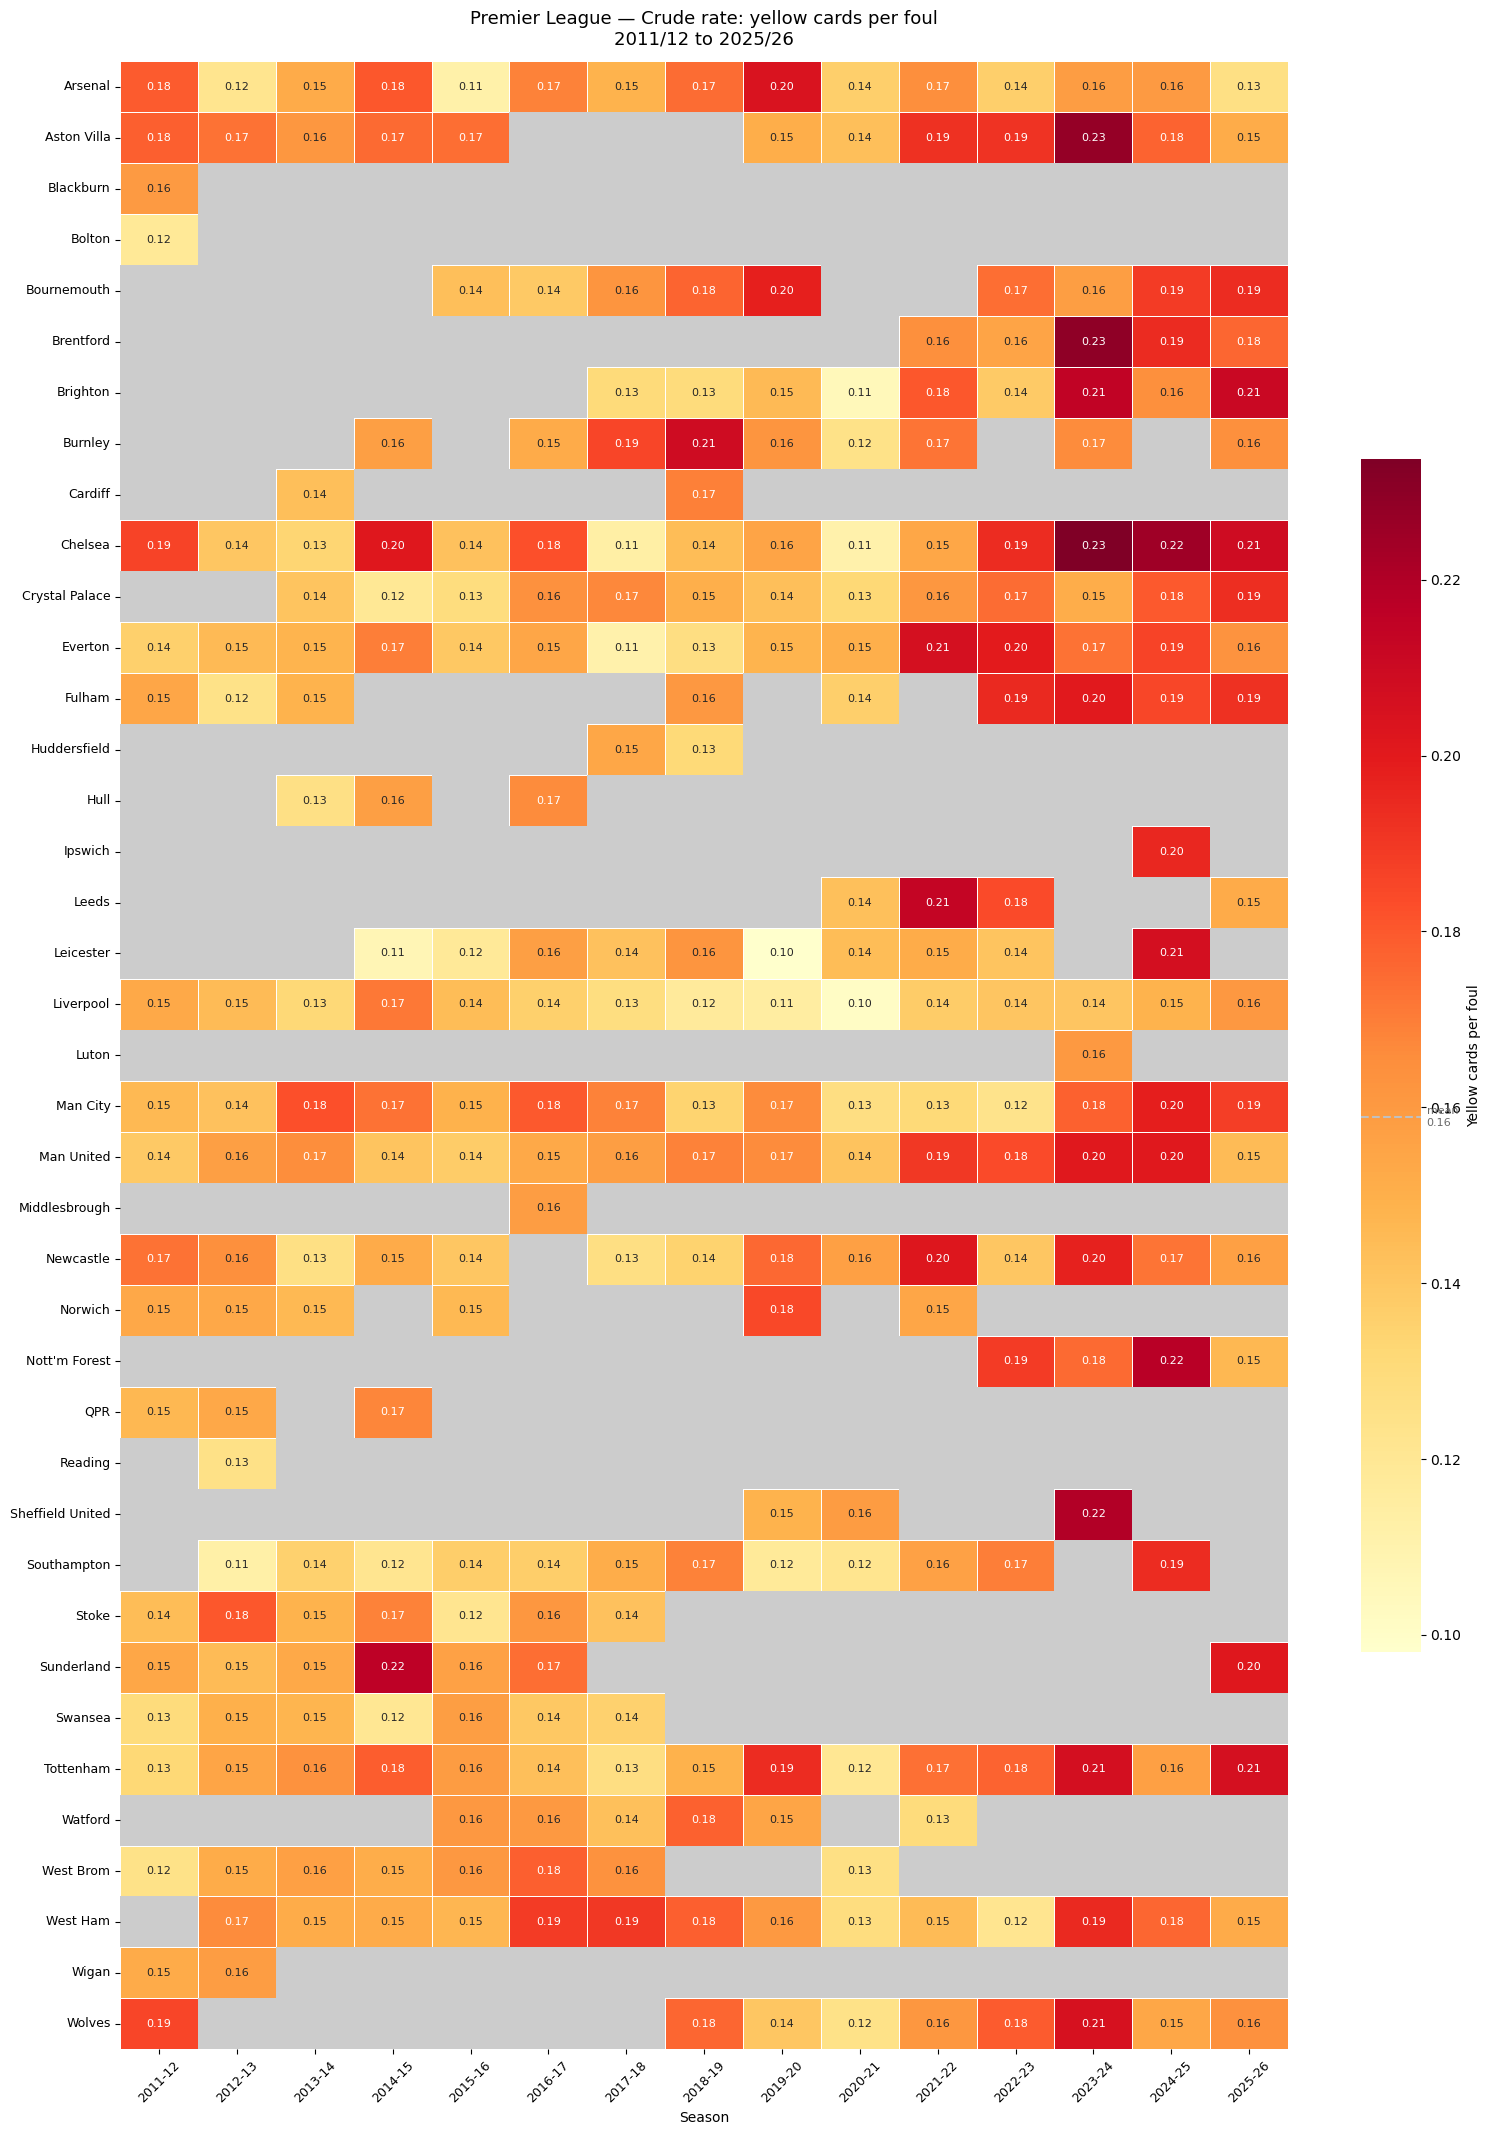

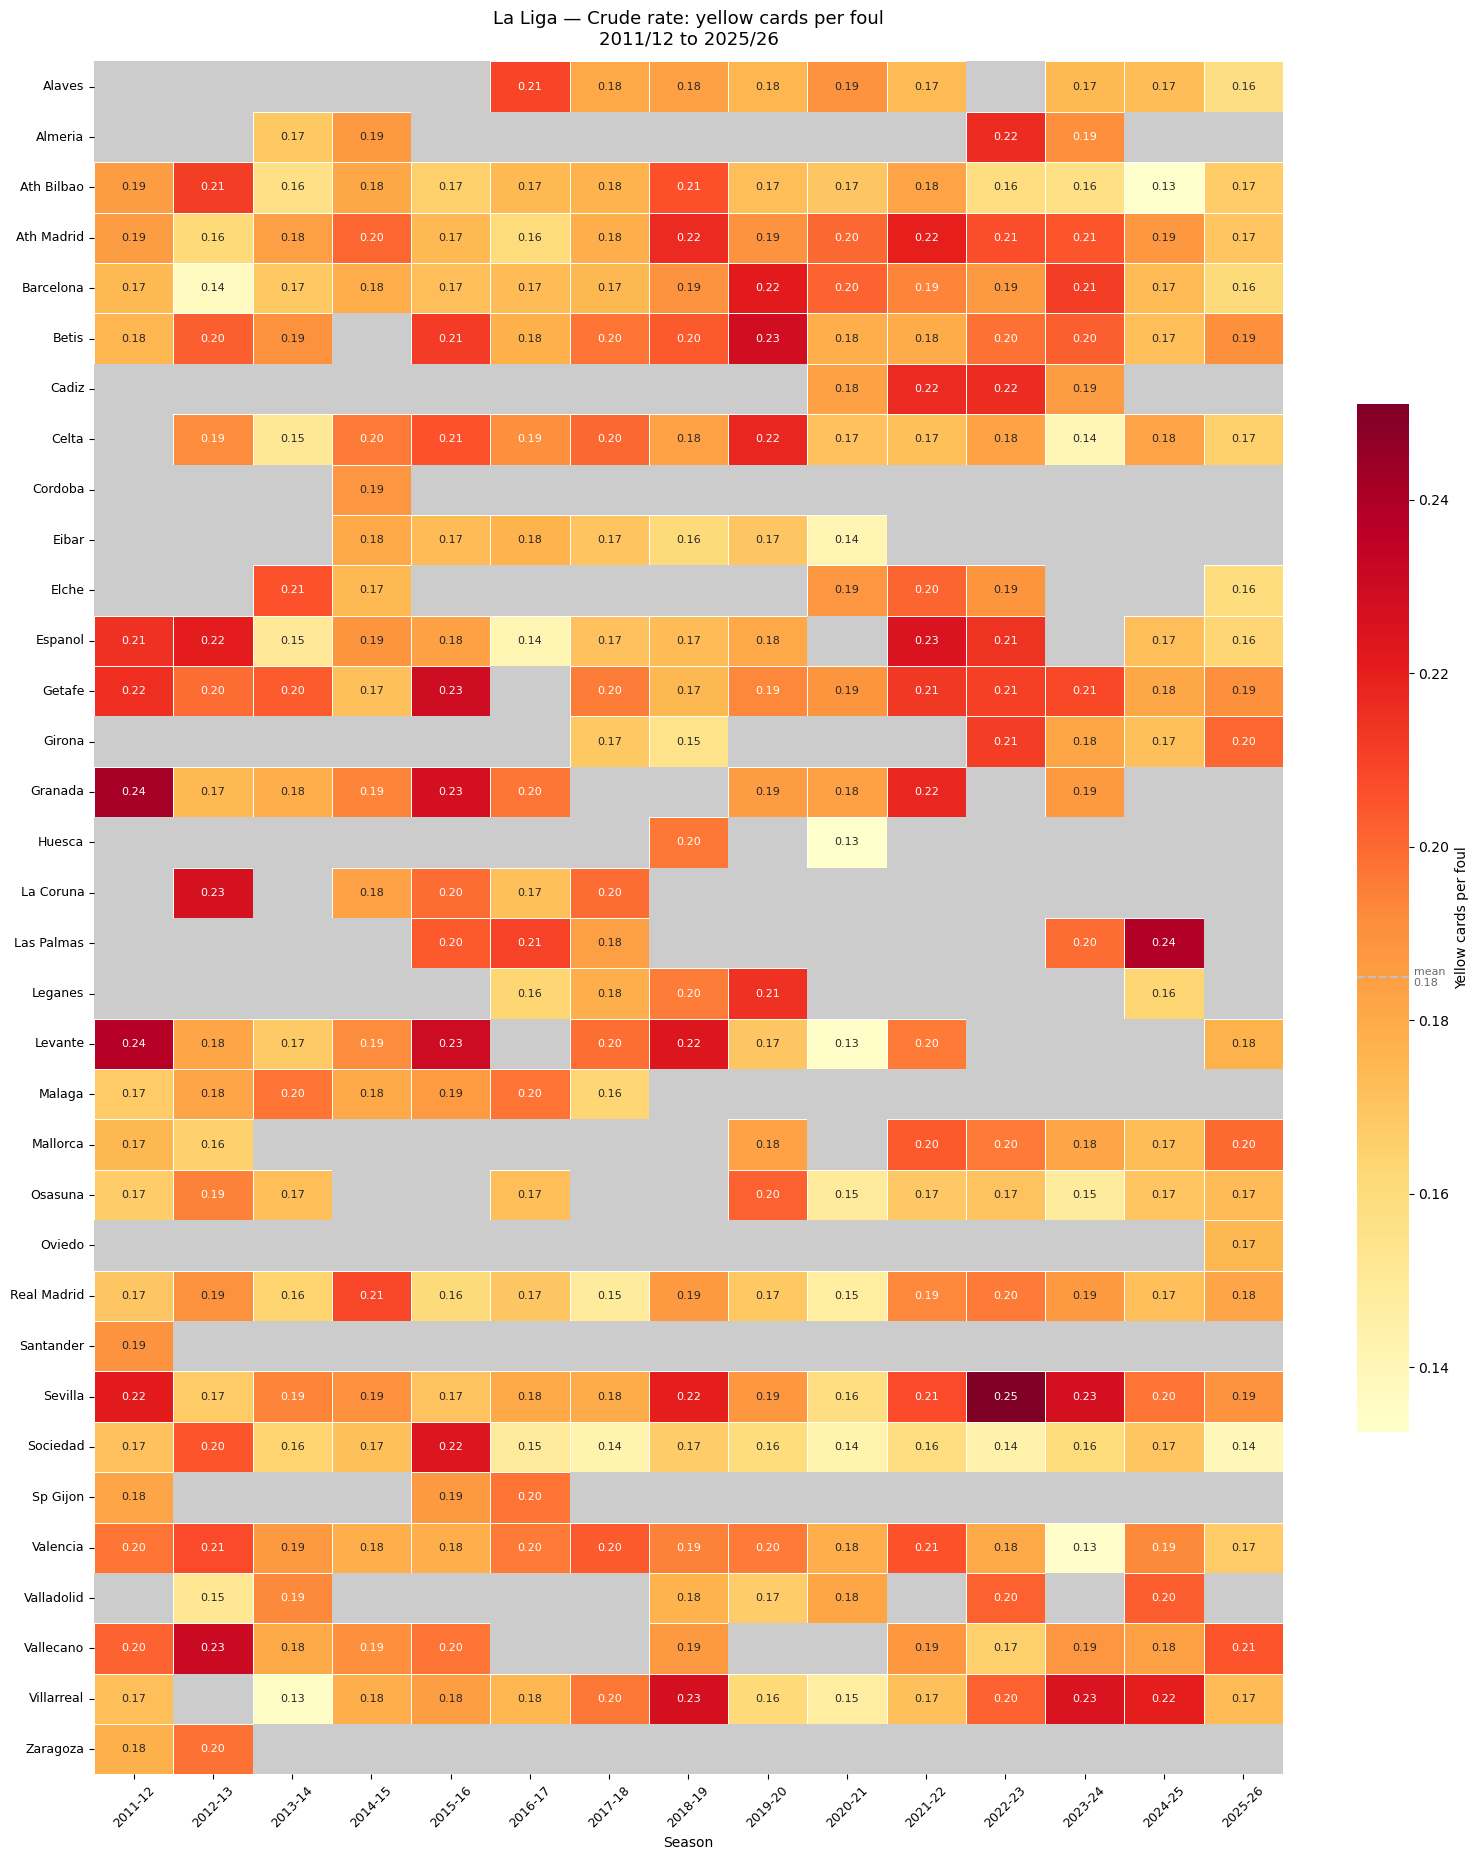

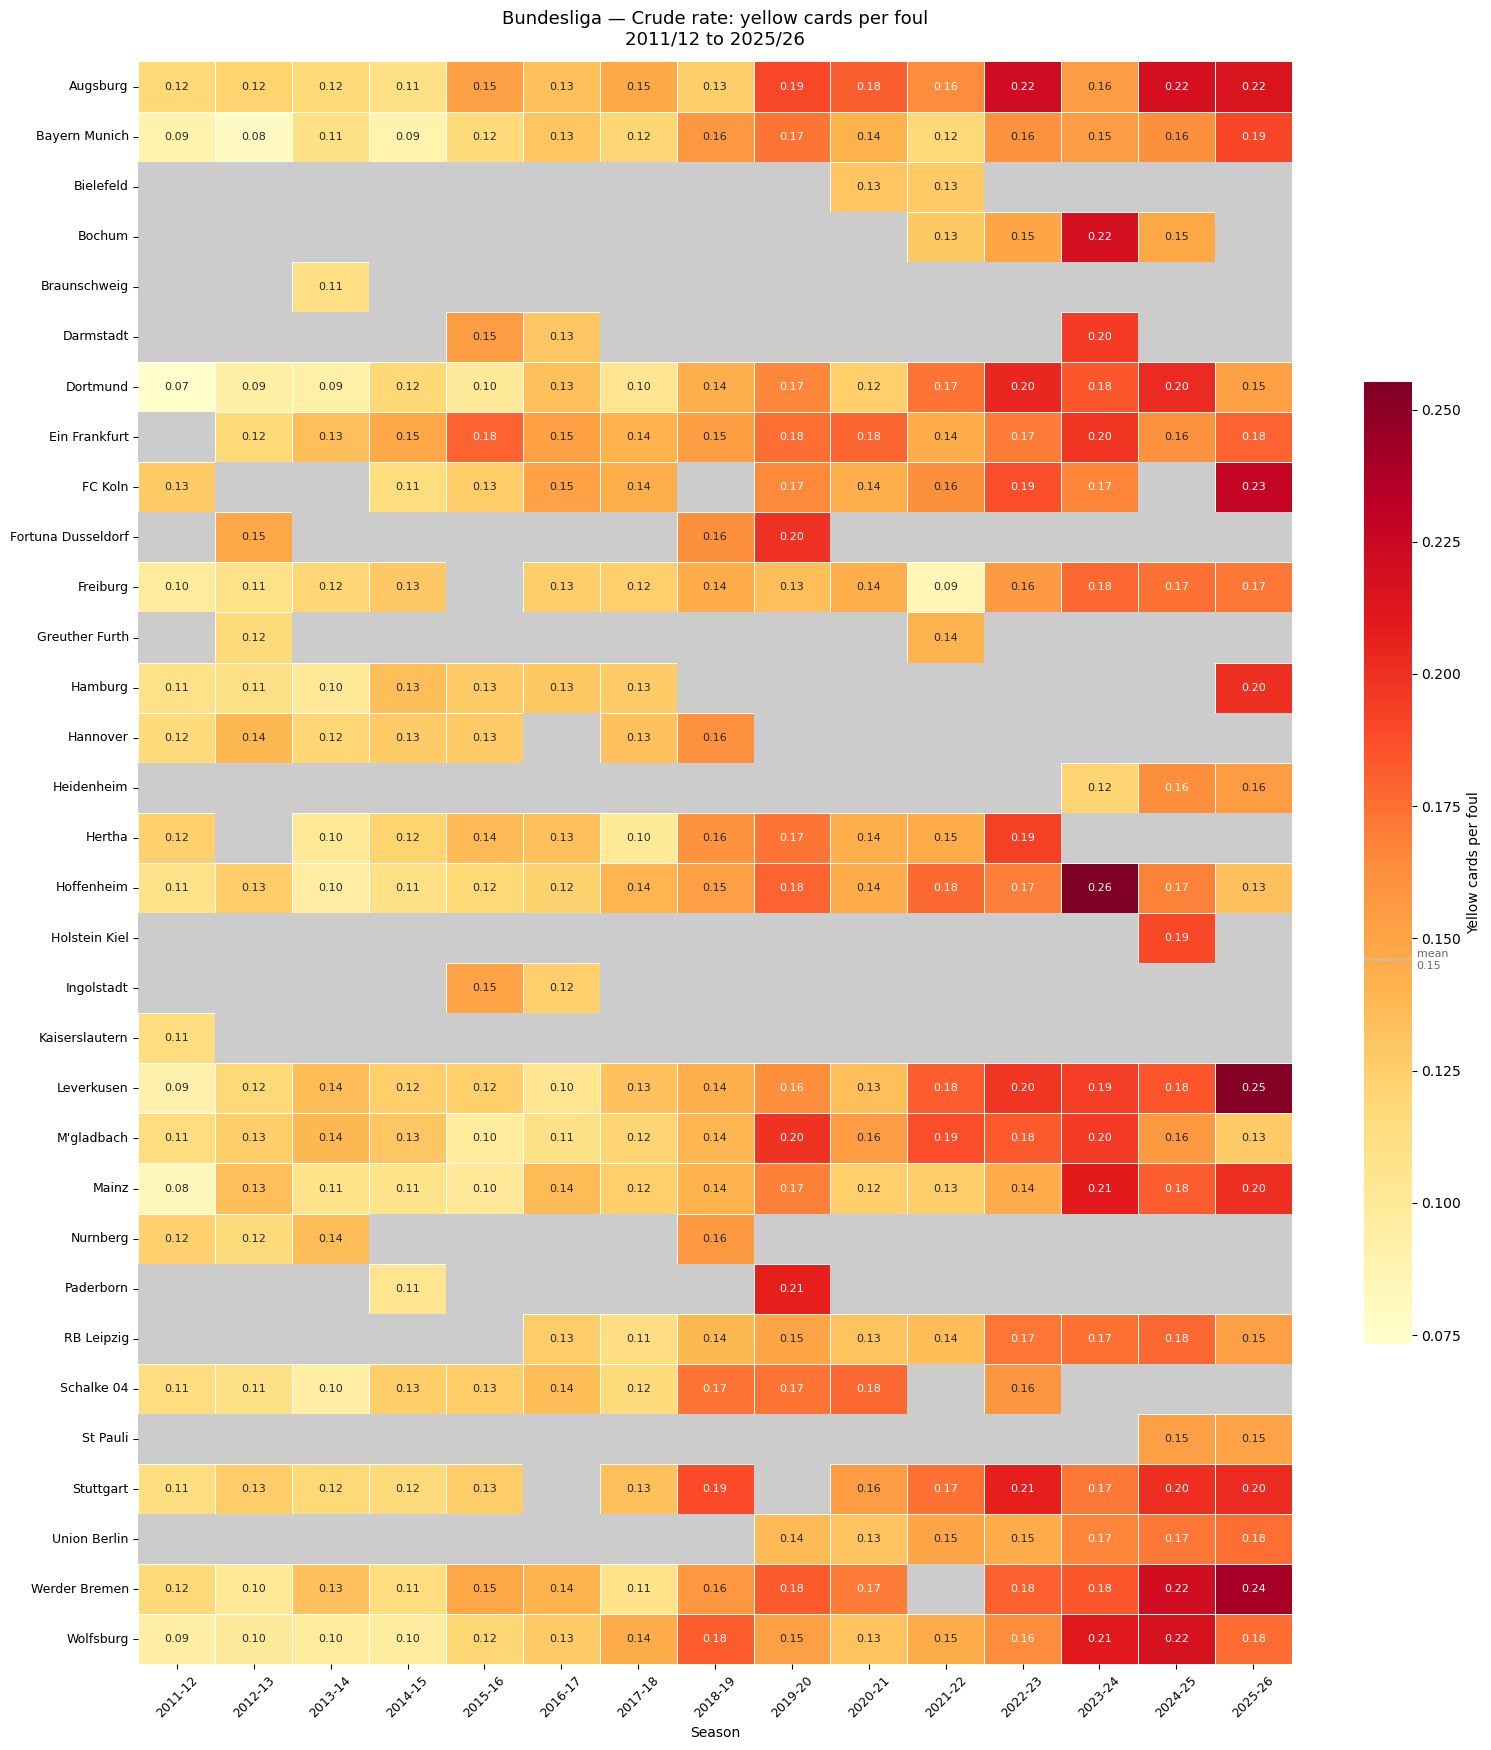

In [11]:
# Heatmaps — crude rate (one figure per league)
for key, label in LEAGUES.items():
    st   = season_team_all[key]
    teams_sorted = sorted(st['team'].unique())

    pv = st.pivot(index='team', columns='season', values='crude_rate')
    pv = pv.reindex(index=teams_sorted, columns=seasons)
    pv.columns = readable_seasons

    fig, ax = plt.subplots(figsize=(16, max(10, len(teams_sorted) * 0.55)))

    sns.heatmap(pv, ax=ax, cmap='YlOrRd', linewidths=0.5, linecolor='white',
                annot=True, fmt='.2f', annot_kws={'size': 8},
                cbar_kws={'label': 'Yellow cards per foul', 'shrink': 0.6},
                mask=pv.isna())
    grey_missing(ax, pv, teams_sorted, readable_seasons)

    overall_mean = st['crude_rate'].mean()
    cbar = ax.collections[0].colorbar
    cbar.ax.axhline(y=overall_mean, color='silver', linestyle='--', linewidth=1.5)
    cbar.ax.text(1.1, overall_mean, f'mean\n{overall_mean:.2f}',
                 va='center', ha='left', fontsize=8, color='dimgrey',
                 transform=cbar.ax.get_yaxis_transform())

    ax.set_title(f'{label} — Crude rate: yellow cards per foul\n2011/12 to 2025/26',
                 fontsize=13, pad=12)
    ax.set_xlabel('Season', fontsize=10)
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)
    plt.tight_layout()
    plt.show()

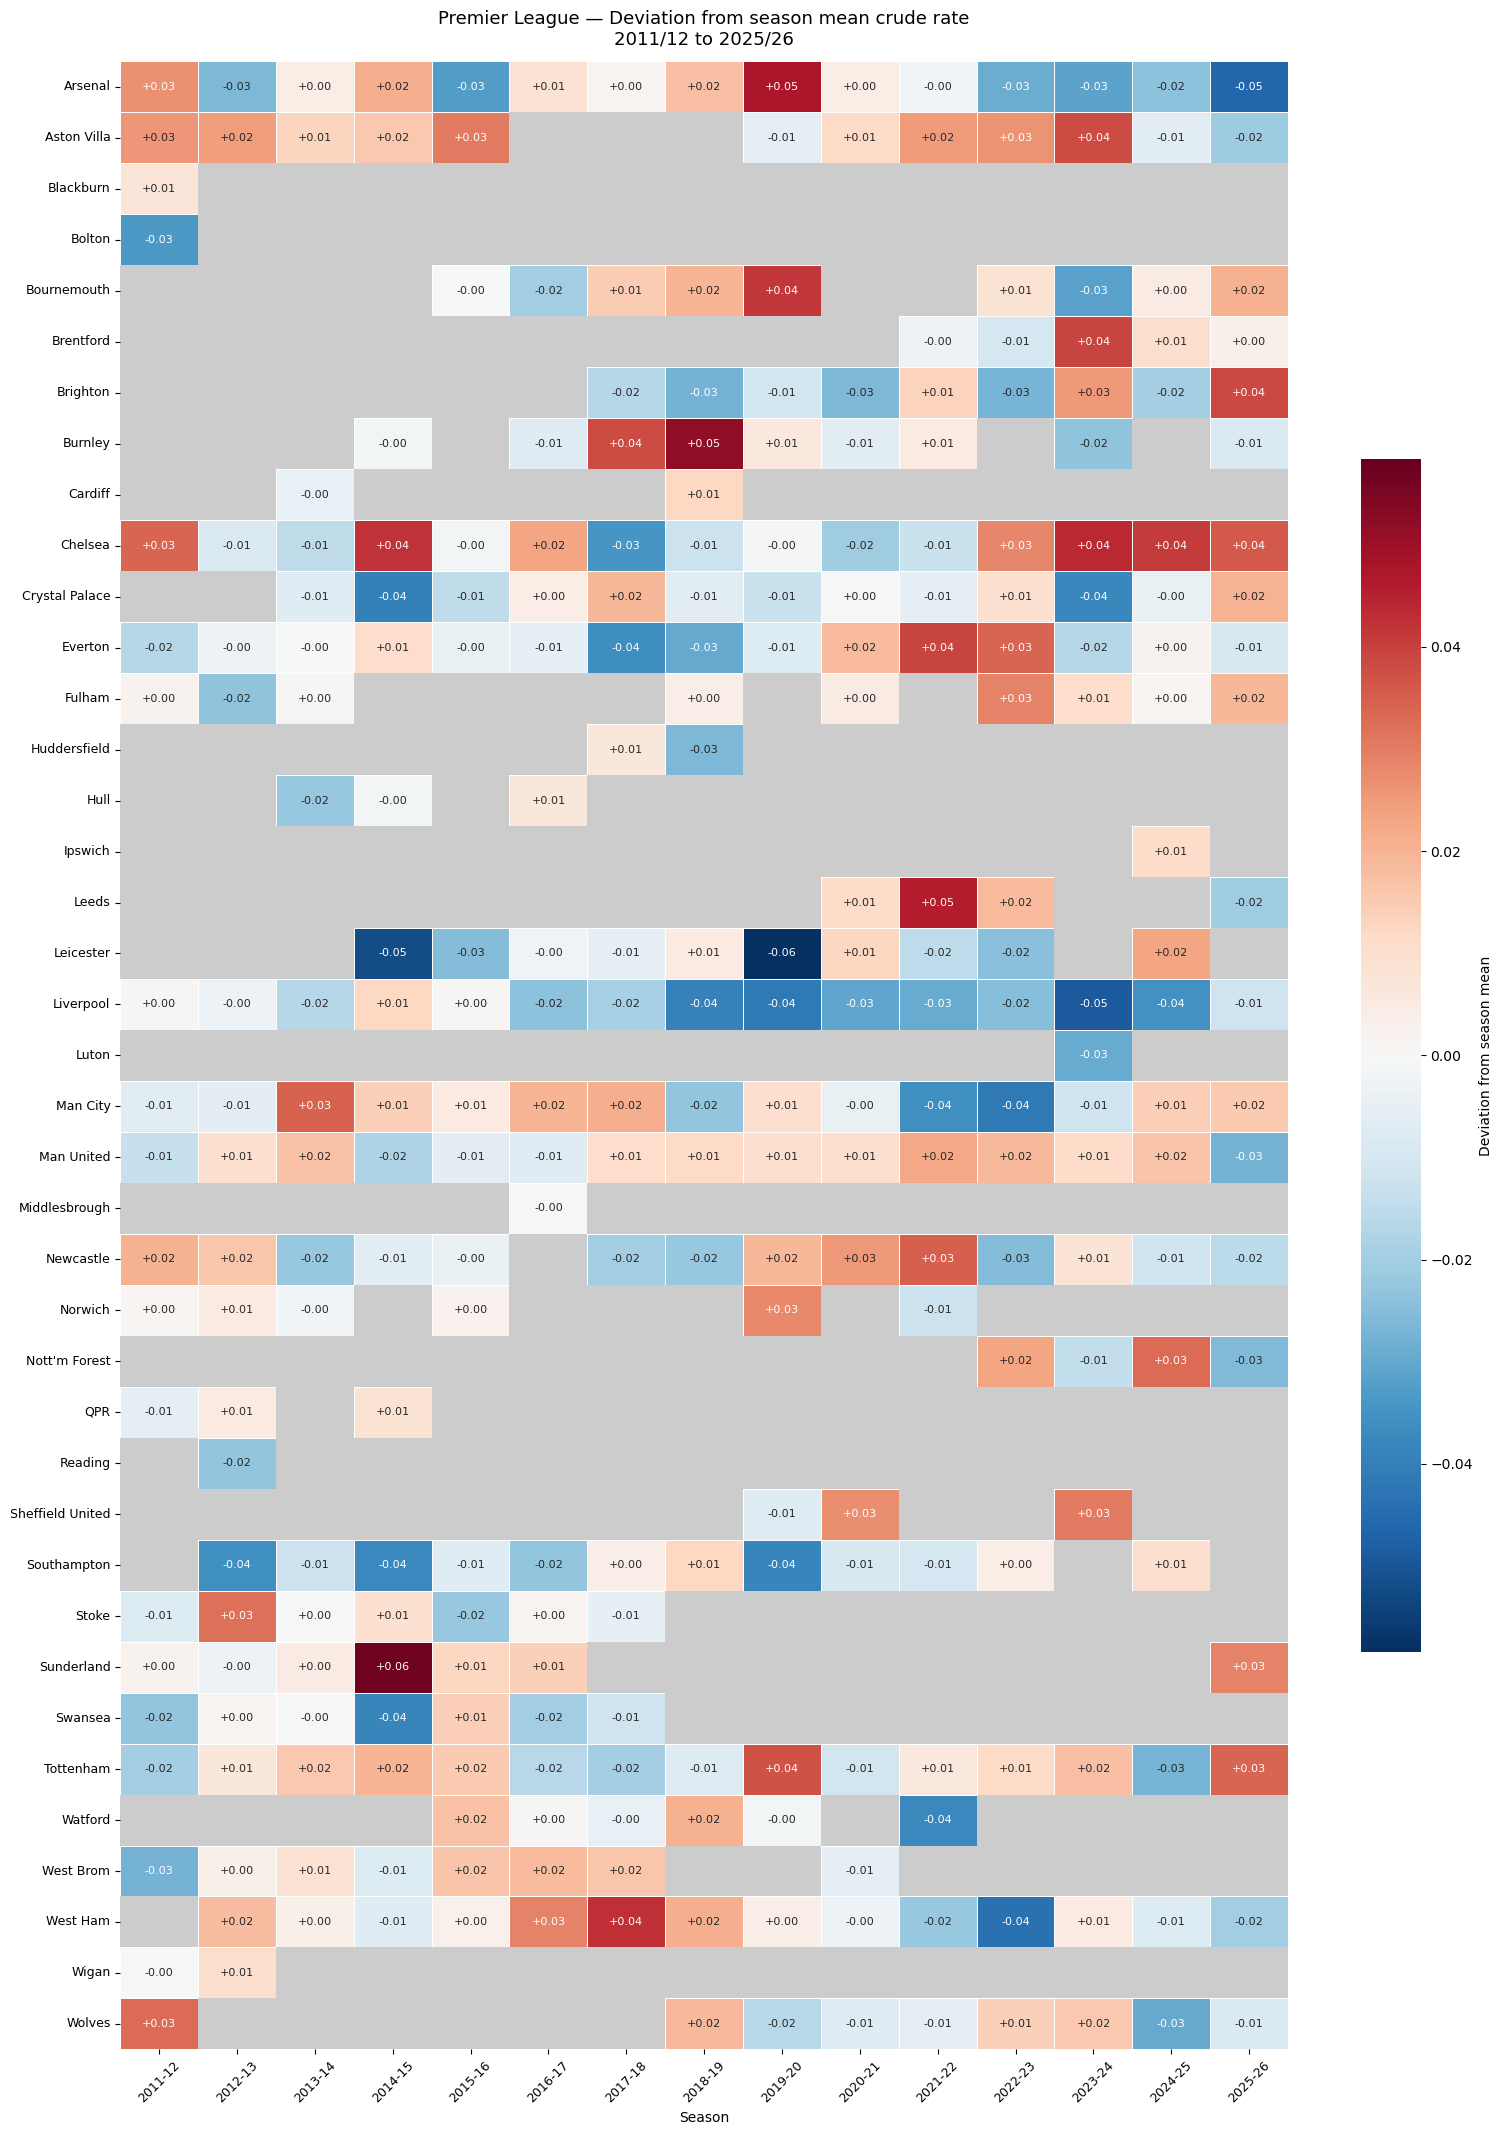

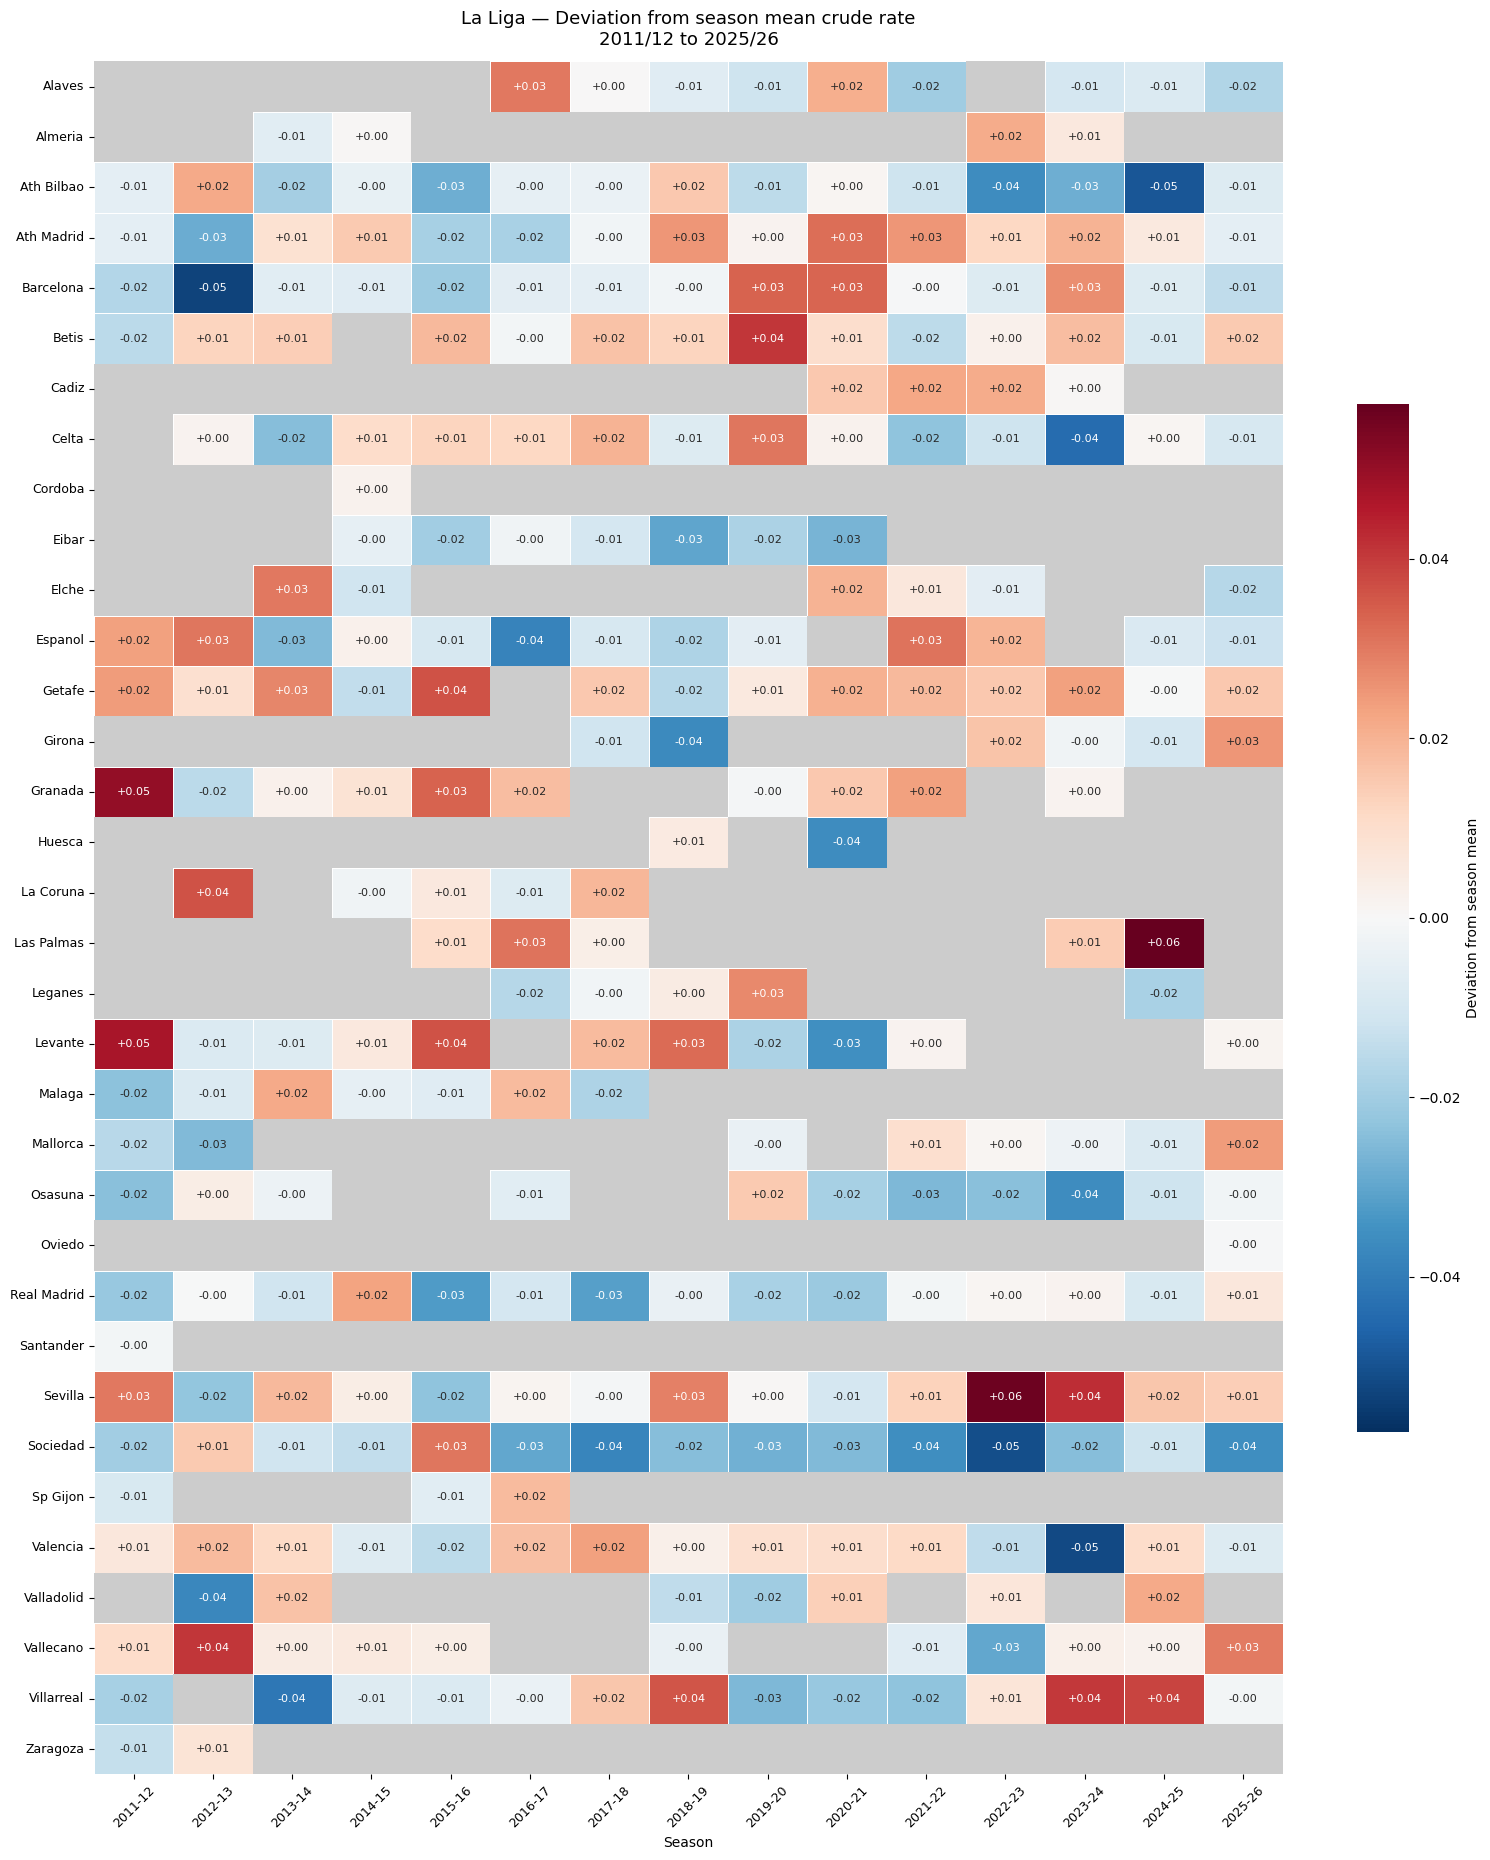

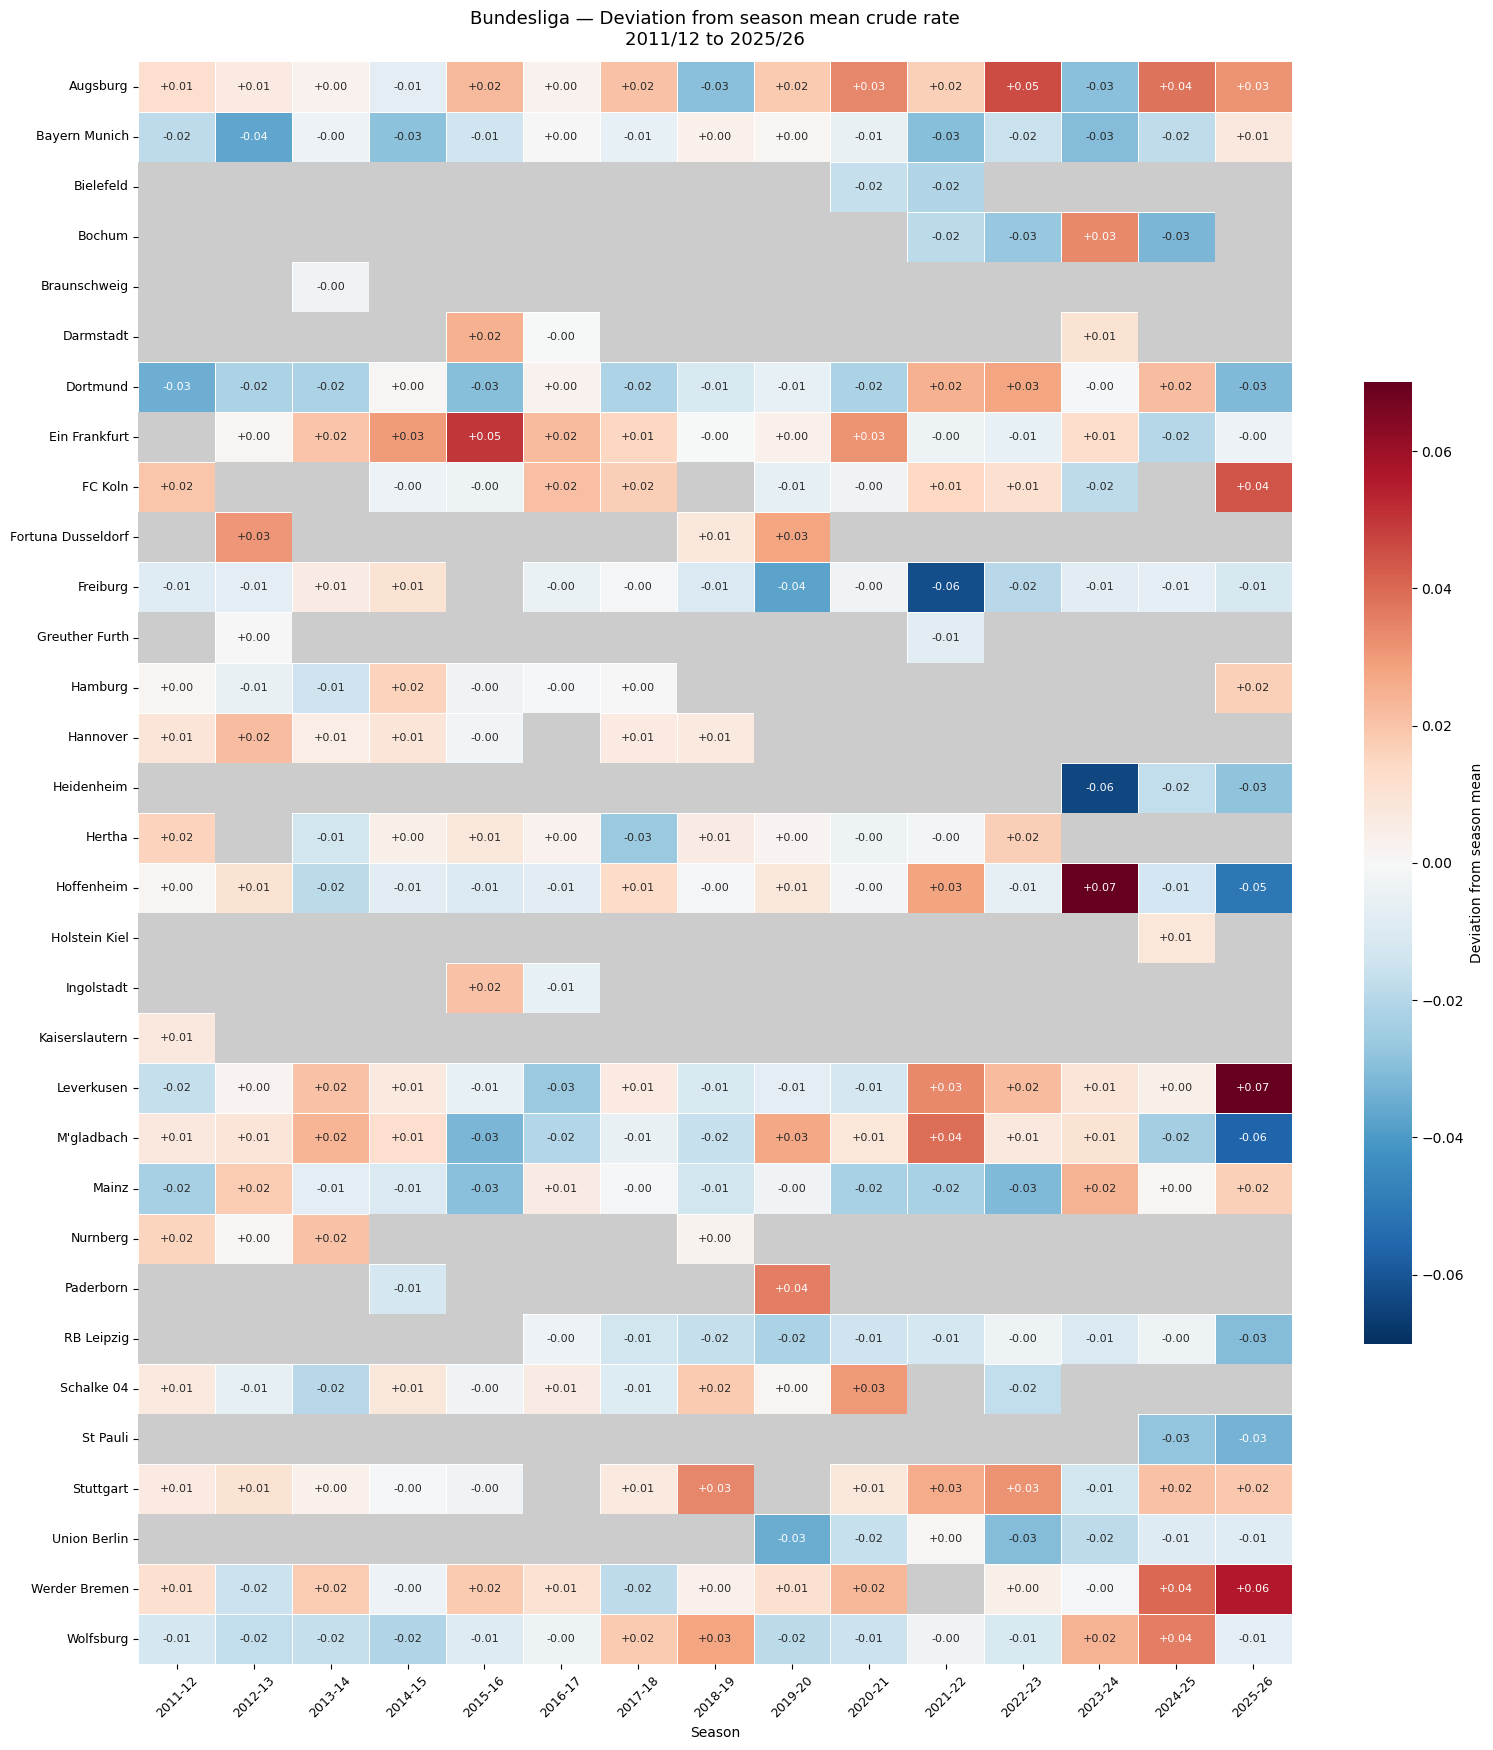

In [12]:
# Heatmaps — deviation from season mean (one figure per league)
for key, label in LEAGUES.items():
    st   = season_team_all[key]
    teams_sorted = sorted(st['team'].unique())

    pv = st.pivot(index='team', columns='season', values='deviation')
    pv = pv.reindex(index=teams_sorted, columns=seasons)
    pv.columns = readable_seasons

    vmax = pv.abs().max().max()

    fig, ax = plt.subplots(figsize=(16, max(10, len(teams_sorted) * 0.55)))

    sns.heatmap(pv, ax=ax, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
                linewidths=0.5, linecolor='white',
                annot=True, fmt='+.2f', annot_kws={'size': 8},
                cbar_kws={'label': 'Deviation from season mean', 'shrink': 0.6},
                mask=pv.isna())
    grey_missing(ax, pv, teams_sorted, readable_seasons)

    ax.set_title(f'{label} — Deviation from season mean crude rate\n2011/12 to 2025/26',
                 fontsize=13, pad=12)
    ax.set_xlabel('Season', fontsize=10)
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)
    plt.tight_layout()
    plt.show()

### Visual observations

The heatmaps give a first qualitative impression before any formal testing.

**Premier League.**  The distribution appears relatively homogeneous — no team
shows a persistent dark or light band across many seasons.  Arsenal have a
notably light band in recent seasons, consistent with the 2025/26 signal found
above.  There is no obvious equivalent of the Juventus stripe visible in the
Serie A heatmap.

**La Liga.**  The quietest visual of the three leagues, confirming the 2025/26
impression.  No team stands out with a persistent colour.  The deviation heatmap
shows a mix of blue and red cells distributed without clear pattern, suggesting
card rates cluster tightly around the league mean across clubs and seasons.

**Bundesliga.**  More variance visible than La Liga, slightly less than Serie A.
Leverkusen's recent red band is visible, as is the generally darker shading for
Werder Bremen in some seasons.  Bayern Munich shows no persistent pattern.

These are visual impressions only.  Section 4 applies the formal z-test screening
to identify which team-season combinations are genuine statistical outliers.

## Section 4 — Screening: which team-season pairs are statistical outliers?

We now run the z-test (normal approximation to the binomial proportion test) for
every team × season pair in each league — the same screening step used in
notebook 04 for Serie A.

The z-test is chosen here for its speed: with ~300 pairs per league to evaluate,
running full bootstrap pipelines at this stage would be expensive and premature.
The z-test is used only as a **filter** to identify which teams appear consistently
across seasons; the rigorous bootstrap and Mann-Whitney tests follow in Section 5.

**Lesson from notebook 04:** counting significant seasons is not enough.
Napoli appeared significant in four Serie A seasons, yet their pooled result was
null — because the significant seasons pointed in opposite directions, cancelling
each other out.  From the start here we record not just *whether* a team was
flagged, but *which side of the distribution* it sat on: above the league mean
(more cards per foul than peers) or below.  A team that flips direction is a
different beast from one that persistently sits on the same side.

Two reference lines appear on the bar chart below:

- **Expected under H0** — if card rates were purely random, we would expect
  roughly 5% of teams to appear significant by chance in any given season
  (1 team per season in an 20-team league, 0.9 in an 18-team Bundesliga).
- The 2025/26 bar is provisional (incomplete season).

In [13]:
def z_screen(df_season):
    """
    Run a two-tailed z-test for every team in a single-season DataFrame.
    Returns a DataFrame with columns: team, n, k, card_rate, league_rate, z, p_z, significant.
    """
    rows = []
    for team in df_season['team'].unique():
        team_df = df_season[df_season['team'] == team]
        rest_df = df_season[df_season['team'] != team]
        n = int(team_df['fouls_committed'].sum())
        k = int(team_df['yellow_cards'].sum())
        if n == 0:
            continue
        p_hat = k / n
        p0    = float(rest_df['yellow_cards'].sum() / rest_df['fouls_committed'].sum())
        se    = np.sqrt(p0 * (1 - p0) / n)
        z     = (p_hat - p0) / se
        p_z   = float(2 * stats.norm.cdf(-abs(z)))
        rows.append(dict(team=team, n=n, k=k,
                         card_rate=round(p_hat, 4),
                         league_rate=round(p0, 4),
                         z=round(z, 3), p_z=round(p_z, 4),
                         significant=p_z < 0.05,
                         direction='high' if p_hat > p0 else 'low'))
    return pd.DataFrame(rows)

# Run for all leagues and seasons
screening = {}
for key in LEAGUES:
    parts = []
    for s in seasons:
        df_s = dfs[key][dfs[key]['season'] == s]
        if df_s['team'].nunique() < 3:
            continue
        res = z_screen(df_s)
        res['season'] = s
        parts.append(res)
    screening[key] = pd.concat(parts, ignore_index=True)

print("Screening complete.")
for key, label in LEAGUES.items():
    n_sig = screening[key]['significant'].sum()
    n_total = len(screening[key])
    print(f"  {label}: {n_sig} / {n_total} team-season pairs significant ({100*n_sig/n_total:.1f}%)")

Screening complete.
  Premier League: 35 / 300 team-season pairs significant (11.7%)
  La Liga: 32 / 300 team-season pairs significant (10.7%)
  Bundesliga: 23 / 270 team-season pairs significant (8.5%)


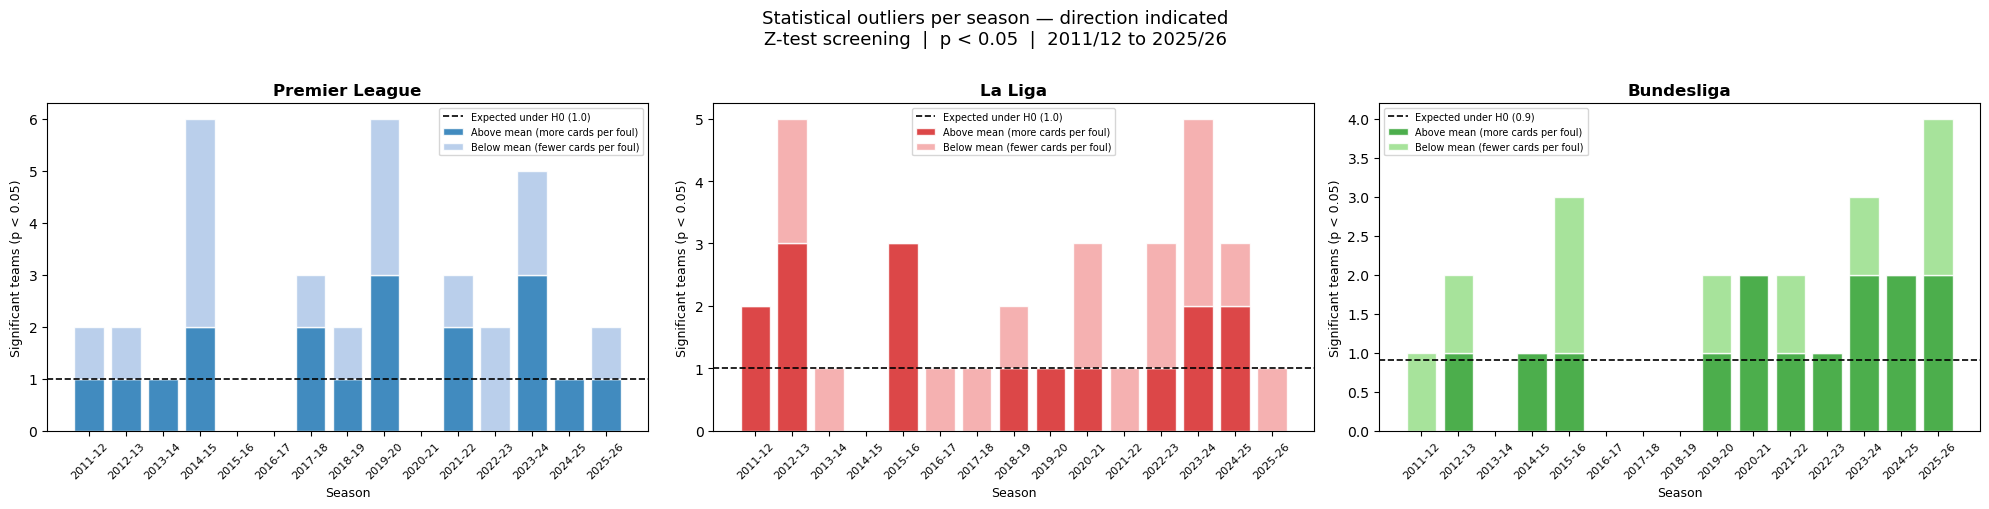

In [14]:
# Stacked bar chart: significant teams per season, split by direction
# Dark shade = above league mean (high card rate), light shade = below (low card rate)
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False)
base_colors = {
    'Premier_League': ('#1f77b4', '#aec7e8'),
    'La_Liga':        ('#d62728', '#f4a4a4'),
    'Bundesliga':     ('#2ca02c', '#98df8a'),
}

for ax, (key, label) in zip(axes, LEAGUES.items()):
    sc = screening[key]
    sig = sc[sc['significant']]

    high = (sig[sig['direction'] == 'high']
            .groupby('season')['team'].count()
            .reindex(seasons, fill_value=0))
    low  = (sig[sig['direction'] == 'low']
            .groupby('season')['team'].count()
            .reindex(seasons, fill_value=0))

    n_teams_typical = sc.groupby('season')['team'].count().median()
    expected = 0.05 * n_teams_typical
    dark, light = base_colors[key]

    ax.bar(readable_seasons, high.values, color=dark,  alpha=0.85,
           edgecolor='white', label='Above mean (more cards per foul)')
    ax.bar(readable_seasons, low.values,  color=light, alpha=0.85,
           edgecolor='white', bottom=high.values,
           label='Below mean (fewer cards per foul)')
    ax.axhline(expected, color='black', linestyle='--', linewidth=1.2,
               label=f'Expected under H0 ({expected:.1f})')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Season', fontsize=9)
    ax.set_ylabel('Significant teams (p < 0.05)', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.legend(fontsize=7)

fig.suptitle('Statistical outliers per season — direction indicated\n'
             'Z-test screening  |  p < 0.05  |  2011/12 to 2025/26',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# Sig-counts table: split by direction
# pct_present = sig_total / seasons the team was actually in the top flight
# (not divided by 15, which would penalise promoted/relegated clubs unfairly)
sig_counts_all = {}
for key, label in LEAGUES.items():
    sc = screening[key]
    sig = sc[sc['significant']]

    seasons_present = sc.groupby('team')['season'].count().rename('seasons_present')
    total = sig.groupby('team')['season'].count().rename('sig_total')
    high  = (sig[sig['direction'] == 'high']
             .groupby('team')['season'].count().rename('sig_high'))
    low   = (sig[sig['direction'] == 'low']
             .groupby('team')['season'].count().rename('sig_low'))

    counts = (pd.concat([seasons_present, total, high, low], axis=1)
              .fillna(0).astype(int)
              .sort_values('sig_total', ascending=False)
              .reset_index())
    counts['pct_present'] = (
        counts['sig_total'] / counts['seasons_present'] * 100
    ).round(1)
    sig_counts_all[key] = counts
    print(f"\n{label} — teams significant in at least 1 season")
    print("(pct_present = significant seasons / seasons in top flight, not % of table total)")
    display(counts[counts['sig_total'] >= 1][
        ['team', 'seasons_present', 'sig_total', 'sig_high', 'sig_low', 'pct_present']
    ])


Premier League — teams significant in at least 1 season
(pct_present = significant seasons / seasons in top flight, not % of table total)


,team,seasons_present,sig_total,sig_high,sig_low,pct_present
0,Chelsea,15,4,4,0,26.7
1,Liverpool,15,3,0,3,20.0
2,Southampton,12,3,0,3,25.0
3,Crystal Palace,13,2,0,2,15.4
4,Arsenal,15,2,1,1,13.3
5,Man City,15,2,1,1,13.3
6,Leicester,10,2,0,2,20.0
7,West Ham,14,2,1,1,14.3
8,Burnley,9,2,2,0,22.2
9,Everton,15,2,1,1,13.3



La Liga — teams significant in at least 1 season
(pct_present = significant seasons / seasons in top flight, not % of table total)


,team,seasons_present,sig_total,sig_high,sig_low,pct_present
0,Villarreal,14,4,3,1,28.6
1,Sociedad,15,4,0,4,26.7
2,Levante,11,3,2,1,27.3
3,Espanol,13,2,1,1,15.4
4,Sevilla,15,2,2,0,13.3
5,Ath Bilbao,15,2,0,2,13.3
6,Granada,10,2,2,0,20.0
7,Osasuna,11,1,0,1,9.1
8,Valencia,15,1,0,1,6.7
9,Ath Madrid,15,1,1,0,6.7



Bundesliga — teams significant in at least 1 season
(pct_present = significant seasons / seasons in top flight, not % of table total)


,team,seasons_present,sig_total,sig_high,sig_low,pct_present
0,Augsburg,15,3,3,0,20.0
1,Ein Frankfurt,14,3,3,0,21.4
2,M'gladbach,15,3,1,2,20.0
3,Hoffenheim,15,2,1,1,13.3
4,Werder Bremen,14,2,2,0,14.3
5,Dortmund,15,1,0,1,6.7
6,Bochum,4,1,1,0,25.0
7,Bayern Munich,15,1,0,1,6.7
8,Leverkusen,15,1,1,0,6.7
9,Mainz,15,1,0,1,6.7


### Screening observations and candidate selection

All three leagues show a significant-team rate above the 5% expected under a pure
null: Premier League 11.7%, La Liga 10.7%, Bundesliga 8.5%.  The Bundesliga is
closest to chance levels, consistent with having the fewest absolute outliers per
season in the bar chart.

**Premier League.**  Chelsea (4 seasons), Liverpool (3) and Southampton (3) cross
the 3-season threshold.  The two most-watched clubs in world football — Arsenal
and Manchester City — appear in only 2 seasons each and do not qualify as
candidates under the data-driven threshold.

**La Liga.**  The two top candidates are Real Sociedad (4 seasons) and Villarreal
(4 seasons) — both mid-table clubs.  Levante qualifies with 3 seasons.
**Barcelona appears in only 1 season; Real Madrid and Atletico Madrid do not appear
at all.**  The most scrutinised club in football produces no persistent signal.

**Bundesliga.**  Three clubs qualify: Augsburg (3), Eintracht Frankfurt (3) and
Borussia Monchengladbach (3).  Bayern Munich and Borussia Dortmund each appear in
only 1 season.  Leverkusen, whose 2025/26 signal was noted in Section 2, also
appears in only 1 season.

**Direction changes the story.**  The counts alone suggested Chelsea, Liverpool and
Southampton as PL candidates — but direction confirms all three are worth taking
forward for different reasons.  Chelsea is 4/4 **high** (consistently more cards
per foul); Liverpool and Southampton are 3/3 **low** (consistently fewer).
These are opposite effects, not the same phenomenon.

Arsenal, by contrast, splits 1 high + 1 low — like Napoli in Serie A, the two
seasons cancel each other out.  Their 2025/26 signal noted in Section 2 is not
backed by a consistent historical pattern.  Same for Manchester City (1H + 1L),
West Ham, and Everton.

In La Liga, Real Sociedad stands out with **4/4 low** — the cleanest persistent
signal in any of the three leagues.  Villarreal is 3H + 1L, predominantly high.
Levante is mixed (2H + 1L) and less convincing as a candidate.

In the Bundesliga, Augsburg and Eintracht Frankfurt are both **3/3 high** —
perfectly consistent direction.  Borussia M'gladbach reaches 3 total seasons but
splits 1H + 2L, making it the M'gladbach equivalent of Arsenal: count looks
impressive, direction does not.

**The first major finding.**  In Serie A, the candidates were the historically
dominant clubs — Inter, Juventus, Lazio.  Here, dominant clubs either show no
signal (Real Madrid, Bayern Munich, Manchester City) or a split directional pattern
(Arsenal).  The consistent outliers are predominantly **mid-table clubs**: Sociedad,
Augsburg, Frankfurt, Southampton.  Liverpool is the one top club with a clean
persistent low-rate signal — the closest thing to the Italian pattern in any of
the three leagues.

**Revised candidate lists for Section 5:**

| League | Team | Source | Screening direction |
|--------|------|--------|---------------------|
| Premier League | Chelsea | Data-driven (4 seasons) | Consistently HIGH |
| Premier League | Liverpool | Data-driven (3 seasons) | Consistently LOW |
| Premier League | Southampton | Data-driven (3 seasons) | Consistently LOW |
| Premier League | Arsenal | Editorial | Split (1H + 1L) |
| Premier League | Man City | Editorial | Split (1H + 1L) |
| Premier League | Man United | Editorial | No signal |
| La Liga | Real Sociedad | Data-driven (4 seasons) | Consistently LOW |
| La Liga | Villarreal | Data-driven (4 seasons) | Predominantly HIGH |
| La Liga | Real Madrid | Editorial | No signal |
| La Liga | Barcelona | Editorial | 1 season LOW |
| La Liga | Atletico Madrid | Editorial | 1 season HIGH |
| Bundesliga | Augsburg | Data-driven (3 seasons) | Consistently HIGH |
| Bundesliga | Eintracht Frankfurt | Data-driven (3 seasons) | Consistently HIGH |
| Bundesliga | M'gladbach | Data-driven (3 seasons) | Mixed (1H + 2L) |
| Bundesliga | Bayern Munich | Editorial | 1 season LOW |
| Bundesliga | Borussia Dortmund | Editorial | 1 season LOW |

**Why include the historically dominant clubs?**  One hypothesis we are testing is
whether the history and prestige of a club influences how referees apply discipline.
In notebook 04, Inter and Juventus — the two most historically dominant clubs in
Italy — emerged as strong persistent outliers with *fewer* cards per foul than the
rest of Serie A.  The editorial additions here allow us to ask the same question for
Real Madrid, Bayern Munich, Manchester City and others: do we see the same pattern,
or is Italy unique?  Finding no signal for these clubs is as informative as finding
one.